# Contoh: Index Iklim untuk Data Titik / Stasiun

Notebook ini mendemonstrasikan penggunaan package `rain_indices_pkg`
(`rain_indices`, `temp_indices`) pada data **per-stasiun** (bukan grid),
menggunakan data sintetis.

Alur:
1. Bangun data curah hujan & suhu sintetis untuk beberapa stasiun (format DataFrame).
2. Konversi ke `xr.Dataset` dims `(time, station)` lewat `from_wide_dataframe`.
3. Hitung index curah hujan (`rain_indices`) dan index suhu (`temp_indices`).
4. Export hasil kembali ke `pandas.DataFrame` (long-format) untuk analisis/CSV.


In [8]:
import sys
from pathlib import Path

# Tambahkan folder src/ (satu tingkat di atas notebooks/) ke sys.path
SRC_PATH = "../src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
print("src path terdaftar:", SRC_PATH)


import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from indek_ekstrim import (
    rain_indices,
    temp_indices,
    percentile_indices,
    from_wide_dataframe,
    result_to_dataframe,
)
np.random.seed(42)

src path terdaftar: ../src


## 1. Bangun data curah hujan sintetis (wide format: index=waktu, kolom=stasiun)

In [3]:
stations = ["Stasiun_A", "Stasiun_B", "Stasiun_C", "Stasiun_D"]
dates = pd.date_range("2015-01-01", "2022-12-31", freq="D")

# Curah hujan harian sintetis: sebagian besar hari kering (0 mm),
# beberapa hari hujan dengan intensitas acak (distribusi eksponensial),
# supaya index seperti CDD/CWD/RX1DAY masuk akal.
rain_wide = pd.DataFrame(index=dates, columns=stations, dtype=float)
for st in stations:
    is_wet = np.random.rand(len(dates)) < 0.35          # ~35% hari basah
    amounts = np.random.exponential(scale=12, size=len(dates))
    rain_wide[st] = np.where(is_wet, amounts, 0.0)

rain_wide.index.name = "time"
rain_wide.head()

,Stasiun_A,Stasiun_B,Stasiun_C,Stasiun_D
time,,,,
2015-01-01,0.00000,0.000000,5.947965,0.000000
2015-01-02,0.00000,1.632328,0.000000,0.000000
2015-01-03,0.00000,6.101127,13.568300,0.000000
2015-01-04,0.00000,0.000000,0.000000,0.000000
2015-01-05,19.72174,3.527952,0.000000,5.854452


## 2. Bangun data suhu sintetis (tasmax & tasmin, wide format, unit Kelvin)

In [4]:
# tasmax/tasmin sintetis dengan pola musiman sederhana (sinusoidal) + noise,
# dalam satuan Kelvin (K) supaya convert_units() dari package benar-benar diuji.
doy = dates.dayofyear.values
seasonal = 5 * np.sin(2 * np.pi * (doy - 80) / 365.25)   # variasi musiman ±5°C

tasmax_wide = pd.DataFrame(index=dates, columns=stations, dtype=float)
tasmin_wide = pd.DataFrame(index=dates, columns=stations, dtype=float)
for st in stations:
    base_max = 30 + seasonal + np.random.normal(0, 2, len(dates))   # sekitar 30°C
    base_min = 20 + seasonal + np.random.normal(0, 2, len(dates))   # sekitar 20°C
    tasmax_wide[st] = base_max + 273.15   # ke Kelvin
    tasmin_wide[st] = base_min + 273.15

tasmax_wide.index.name = "time"
tasmin_wide.index.name = "time"
tasmax_wide.head()

,Stasiun_A,Stasiun_B,Stasiun_C,Stasiun_D
time,,,,
2015-01-01,298.426916,296.531090,299.635481,295.994993
2015-01-02,298.020866,300.145096,299.874572,297.616459
2015-01-03,296.692248,298.678983,295.581610,298.638975
2015-01-04,298.652545,297.186174,300.884619,298.535332
2015-01-05,298.662672,296.949510,297.351938,296.299309


## 3. Konversi ke `xr.Dataset` dims `(time, station)`

In [5]:
ds_rain   = from_wide_dataframe(rain_wide, varname="pr", units="mm/day", station_dim="station")
ds_tasmax = from_wide_dataframe(tasmax_wide, varname="tasmax", units="K", station_dim="station")
ds_tasmin = from_wide_dataframe(tasmin_wide, varname="tasmin", units="K", station_dim="station")
ds_tas   = from_wide_dataframe(tasmax_wide, varname="tas", units="K", station_dim="station")

# Gabung semua variabel jadi satu Dataset (time, station)
ds_station = xr.merge([ds_rain, ds_tasmax, ds_tasmin, ds_tas])
ds_station

<xarray.Dataset> Size: 397kB
Dimensions:  (time: 2922, station: 4)
Coordinates:
  * time     (time) datetime64[us] 23kB 2015-01-01 2015-01-02 ... 2022-12-31
  * station  (station) object 32B 'Stasiun_A' 'Stasiun_B' ... 'Stasiun_D'
Data variables:
    pr       (time, station) float64 94kB 0.0 0.0 5.948 0.0 ... 0.0 0.0 0.0 0.0
    tasmax   (time, station) float64 94kB 298.4 296.5 299.6 ... 297.0 300.7
    tasmin   (time, station) float64 94kB 288.2 287.2 289.0 ... 288.6 286.8
    tas      (time, station) float64 94kB 298.4 296.5 299.6 ... 297.0 300.7

## 4. Hitung index curah hujan (`rain_indices`)

Karena data ini per-stasiun (bukan grid lat/lon), fungsi `rain_indices()`
tetap jalan tanpa modifikasi -- `apply_ufunc` di `engine.py` otomatis
broadcast ke dimensi `station` (lihat penjelasan di `stations.py`).

In [6]:
rain_result = rain_indices(
    ds_station,
    varname="pr",
    slice_mode="ANN",
    verbose=True,
)
rain_result

[rain_indices] building graph: RX1DAY
[rain_indices] building graph: RX3DAY
[rain_indices] building graph: RX5DAY
[rain_indices] building graph: RX7DAY
[rain_indices] building graph: RX10DAY
[rain_indices] building graph: HH
[rain_indices] building graph: HH20MM
[rain_indices] building graph: HH50MM
[rain_indices] building graph: HH100MM
[rain_indices] building graph: HH150MM
[rain_indices] building graph: FH20MM
[rain_indices] building graph: FH50MM
[rain_indices] building graph: FH100MM
[rain_indices] building graph: FH150MM
[rain_indices] building graph: PRCPTOT
[rain_indices] building graph: CDD
[rain_indices] building graph: CWD
[rain_indices] building graph: SDII
[rain_indices] building graph: R95P
[rain_indices] building graph: R99P
[rain_indices] building graph: R95PTOT
[rain_indices] building graph: R99PTOT
[rain_indices] computing 22 indices in parallel...


<xarray.Dataset> Size: 6kB
Dimensions:  (station: 4, year: 8)
Coordinates:
  * station  (station) object 32B 'Stasiun_A' 'Stasiun_B' ... 'Stasiun_D'
  * year     (year) int64 64B 2015 2016 2017 2018 2019 2020 2021 2022
Data variables: (12/22)
    RX1DAY   (year, station) float64 256B 50.28 51.22 47.91 ... 57.62 44.57
    RX3DAY   (year, station) float64 256B 86.85 84.54 76.88 ... 73.56 65.76
    RX5DAY   (year, station) float64 256B 86.85 118.5 86.67 ... 75.41 81.53
    RX7DAY   (year, station) float64 256B 87.83 118.5 101.5 ... 84.27 102.6
    RX10DAY  (year, station) float64 256B 110.6 143.1 111.6 ... 131.6 119.4
    HH       (year, station) float64 256B 125.0 125.0 130.0 ... 118.0 121.0
    ...       ...
    CWD      (year, station) float64 256B 4.0 4.0 8.0 4.0 ... 5.0 6.0 6.0 5.0
    SDII     (year, station) float64 256B 13.0 11.89 10.73 ... 12.88 12.3 12.11
    R95P     (year, station) float64 256B 282.3 295.3 263.1 ... 282.9 244.8
    R99P     (year, station) float64 256B 92.47 98.19 90.28 ... 112.4 87.41
    R95PTOT  (year, station) float64 256B 17.37 19.87 18.86 ... 19.49 16.71
    R99PTOT  (year, station) float64 256B 5.69 6.606 6.47 ... 8.348 7.742 5.965

## 5. Hitung index suhu (`temp_indices`)

In [7]:
temp_result = temp_indices(
    ds_station,
    slice_mode="ANN",
    verbose=True,
    # ds_station tidak punya 'tas', jadi TMm otomatis di-skip (lihat pesan SKIP di bawah)
)
temp_result

[temp_indices] preparing variable: tasmax
[temp_indices] building graph: TXx (var=['tasmax'])
[temp_indices] building graph: TXn (var=['tasmax'])
[temp_indices] building graph: TXm (var=['tasmax'])
[temp_indices] preparing variable: tasmin
[temp_indices] building graph: TNx (var=['tasmin'])
[temp_indices] building graph: TNn (var=['tasmin'])
[temp_indices] building graph: TNm (var=['tasmin'])
[temp_indices] preparing variable: tas
[temp_indices] building graph: TMx (var=['tas'])
[temp_indices] building graph: TMn (var=['tas'])
[temp_indices] building graph: TMm (var=['tas'])
[temp_indices] building graph: FD (var=['tasmin'])
[temp_indices] building graph: ID (var=['tasmax'])
[temp_indices] building graph: SU (var=['tasmax'])
[temp_indices] building graph: TR (var=['tasmin'])
[temp_indices] building graph: DTR (var=['tasmax', 'tasmin'])
[temp_indices] building graph: ETR (var=['tasmax', 'tasmin'])
[temp_indices] computing 15 indices in parallel...


<xarray.Dataset> Size: 4kB
Dimensions:  (station: 4, year: 8)
Coordinates:
  * station  (station) object 32B 'Stasiun_A' 'Stasiun_B' ... 'Stasiun_D'
  * year     (year) int64 64B 2015 2016 2017 2018 2019 2020 2021 2022
Data variables: (12/15)
    TXx      (year, station) float64 256B 40.04 38.24 38.68 ... 41.95 40.41
    TXn      (year, station) float64 256B 19.76 21.41 21.54 ... 19.02 21.27
    TXm      (year, station) float64 256B 29.95 29.96 30.09 ... 30.05 30.19
    TNx      (year, station) float64 256B 27.92 28.86 28.48 ... 29.75 28.96
    TNn      (year, station) float64 256B 11.05 10.61 11.15 ... 11.46 10.41
    TNm      (year, station) float64 256B 20.04 19.95 20.23 ... 20.03 20.15
    ...       ...
    FD       (year, station) float64 256B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ID       (year, station) float64 256B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SU       (year, station) float64 256B 323.0 319.0 319.0 ... 322.0 326.0
    TR       (year, station) float64 256B 189.0 187.0 198.0 ... 180.0 193.0
    DTR      (year, station) float64 256B 9.903 10.02 9.861 ... 10.02 10.05
    ETR      (year, station) float64 256B 28.99 27.63 27.53 ... 29.57 30.48 30.0

In [ ]:
## 5. Hitung index suhu berbasis persentil

In [12]:
temp_result = percentile_indices(
    ds_station,
    base_period=("1981-01-01", "2010-12-31"),   # periode referensi
    slice_mode="ANN",
    indices=["tx90", "tn10", "wsdi", "csdi"],   # opsional, default semua
    # ds_station tidak punya 'tas', jadi TMm otomatis di-skip (lihat pesan SKIP di bawah)
)
temp_result

[percentile_indices] preparing variable: tasmax
[percentile_indices] computing baseline threshold: var=tasmax q=0.9
[percentile_indices] building graph: tx90
[percentile_indices] preparing variable: tasmin
[percentile_indices] computing baseline threshold: var=tasmin q=0.1
[percentile_indices] building graph: tn10
[percentile_indices] building graph: wsdi
[percentile_indices] building graph: csdi
[percentile_indices] computing 4 indices in parallel...


<xarray.Dataset> Size: 1kB
Dimensions:  (station: 4, year: 8)
Coordinates:
  * station  (station) object 32B 'Stasiun_A' 'Stasiun_B' ... 'Stasiun_D'
  * year     (year) int64 64B 2015 2016 2017 2018 2019 2020 2021 2022
Data variables:
    tx90     (year, station) float64 256B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    tn10     (year, station) float64 256B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    wsdi     (year, station) float64 256B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    csdi     (year, station) float64 256B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

## 6. Lihat hasil sebagai DataFrame (long-format), siap diekspor ke CSV

In [8]:
rain_df = result_to_dataframe(rain_result, station_dim="station")
temp_df = result_to_dataframe(temp_result, station_dim="station")

print(rain_df.head())
print(temp_df.head())

# Contoh export:
# rain_df.to_csv("rain_indices_stasiun.csv", index=False)
# temp_df.to_csv("temp_indices_stasiun.csv", index=False)

     station  year     RX1DAY     RX3DAY      RX5DAY      RX7DAY     RX10DAY  \
0  Stasiun_A  2015  50.283714  86.846656   86.846656   87.827111  110.570774   
1  Stasiun_A  2016  70.462242  90.006580  101.596519  113.296992  163.990301   
2  Stasiun_A  2017  47.290149  77.346841  102.934798  104.622858  123.047052   
3  Stasiun_A  2018  65.029290  89.850695   94.601763  100.785867  114.679156   
4  Stasiun_A  2019  69.509072  95.899120  111.854443  112.529893  141.616642   

      HH  HH20MM  HH50MM  ...  FH100MM  FH150MM      PRCPTOT   CDD  CWD  \
0  125.0    25.0     1.0  ...      0.0      0.0  1629.754242  11.0  4.0   
1  121.0    22.0     1.0  ...      0.0      0.0  1534.008396   9.0  8.0   
2  117.0    36.0     0.0  ...      0.0      0.0  1680.113699  16.0  5.0   
3  117.0    21.0     2.0  ...      0.0      0.0  1394.090621  11.0  4.0   
4  116.0    25.0     3.0  ...      0.0      0.0  1560.458765  11.0  5.0   

        SDII        R95P        R99P    R95PTOT   R99PTOT  
0  13.00

## 7. Visualisasi cepat: tren salah satu index per stasiun

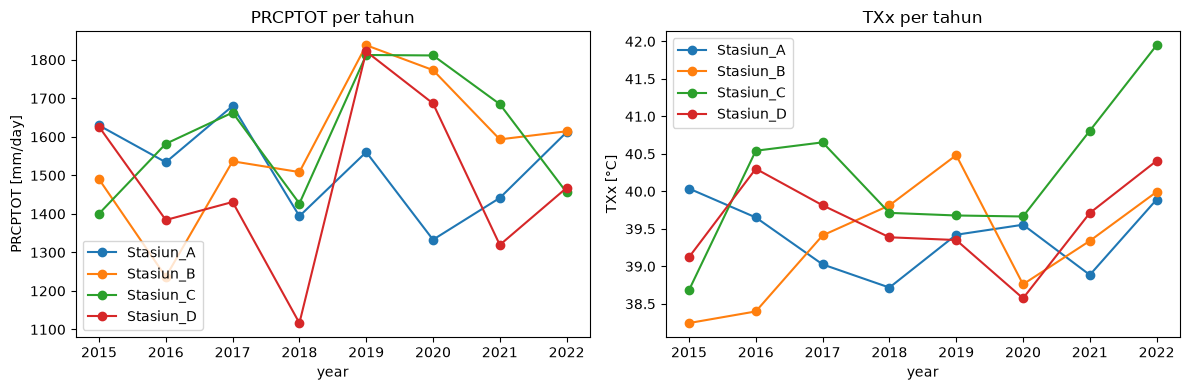

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for st in stations:
    rain_result["PRCPTOT"].sel(station=st).plot(ax=axes[0], marker="o", label=st)
    temp_result["TXx"].sel(station=st).plot(ax=axes[1], marker="o", label=st)

axes[0].set_title("PRCPTOT per tahun")
axes[0].legend()
axes[1].set_title("TXx per tahun")
axes[1].legend()
plt.tight_layout()
plt.show()